In [40]:
from google.colab import auth
auth.authenticate_user()

PROJECT_ID = "bike-case-study-499302"

from google.cloud import bigquery
client = bigquery.Client(project=PROJECT_ID)

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from datetime import datetime

In [42]:
query = """
SELECT *
FROM bikes.trips_cleaned
"""

In [43]:
df = client.query(query).to_dataframe()
df.shape

(5695649, 17)

In [44]:
df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,ride_length_seconds,day_of_week,month,hour
0,48CD8E15C1D70B05,classic_bike,2026-04-04 13:53:54.689000+00:00,2026-04-04 14:19:15.316000+00:00,Canal St & Lake St,CHI02184,Clark St & Armitage Ave,CHI00474,41.885970,-87.639990,41.918306,-87.636282,casual,1520,Saturday,April,13
1,9FECEFBF52E8D19C,classic_bike,2026-03-14 19:04:19.251000+00:00,2026-03-14 19:07:45.653000+00:00,Blackstone Ave & 53rd St,CHI02185,Ellis Ave & 53rd St,CHI00585,41.799620,-87.590130,41.799336,-87.600958,member,206,Saturday,March,19
2,6FFA0BBC8DECCF10,electric_bike,2025-05-12 08:26:30.049000+00:00,2025-05-12 08:37:16.339000+00:00,Clark St & Montrose Ave,KA1503000022,Clark St & Wellington Ave,TA1307000136,41.961588,-87.666036,41.936497,-87.647539,member,646,Monday,May,8
3,19D138D24236A6E8,electric_bike,2025-05-21 17:52:23.480000+00:00,2025-05-21 18:04:07.136000+00:00,Kingsbury St & Kinzie St,KA1503000043,Wood St & Augusta Blvd,657,41.889177,-87.638506,41.899181,-87.672200,member,703,Wednesday,May,17
4,C6AD16E1454FC270,classic_bike,2025-05-01 14:25:16.676000+00:00,2025-05-01 14:51:23.120000+00:00,Dusable Harbor,KA1503000064,Shedd Aquarium,15544,41.886976,-87.612813,41.867226,-87.615355,member,1566,Thursday,May,14


In [45]:
df.groupby('member_casual')['ride_length_seconds'].agg(['mean', 'median', 'count'])

,mean,median,count
member_casual,,,
casual,1346.895205,678.0,2037038
member,745.848552,514.0,3658611


In [46]:
df.groupby('day_of_week')['ride_length_seconds'].agg(['count', 'mean'])

,count,mean
day_of_week,,
Friday,859088,962.962934
Monday,746665,916.375285
Saturday,870225,1147.655603
Sunday,731454,1162.547966
Thursday,870666,865.422815
Tuesday,810003,847.515103
Wednesday,807548,832.022645


In [47]:
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df.groupby('day_of_week')['ride_length_seconds'].agg(['count', 'mean']).reindex(weekday_order)

,count,mean
day_of_week,,
Monday,746665,916.375285
Tuesday,810003,847.515103
Wednesday,807548,832.022645
Thursday,870666,865.422815
Friday,859088,962.962934
Saturday,870225,1147.655603
Sunday,731454,1162.547966


In [48]:
df.groupby(['day_of_week', 'member_casual'])['ride_length_seconds'].agg(['count', 'mean']).reindex(weekday_order, level=0)

count         mean
day_of_week member_casual                     
Monday      casual         232837   1337.31005
            member         513828   725.632103
Tuesday     casual         229182  1170.218058
            member         580821   720.182054
Wednesday   casual         229366  1128.012138
            member         578182   714.602999
Thursday    casual         268739  1190.719088
            member         601927   720.189598
Friday      casual         320443  1334.229292
            member         538645   742.094448
Saturday    casual         416420  1508.325609
            member         453805   816.698024
Sunday      casual         340051  1557.845332
            member         391403    819.11354

In [49]:
df['rideable_type'].value_counts()

,count
rideable_type,
electric_bike,3759336
classic_bike,1936313


In [50]:
df.groupby(['member_casual', 'rideable_type'])['ride_id'].count().rename('ride_count')

member_casual  rideable_type
casual         classic_bike      662953
               electric_bike    1374085
member         classic_bike     1273360
               electric_bike    2385251
Name: ride_count, dtype: int64

In [51]:
df.groupby(['day_of_week', 'rideable_type'])['ride_length_seconds'].agg(['count', 'mean']).reindex(weekday_order, level=0)

count         mean
day_of_week rideable_type                     
Monday      classic_bike   264539  1307.004275
            electric_bike  482126   702.040023
Tuesday     classic_bike   274348  1199.038036
            electric_bike  535655   667.474567
Wednesday   classic_bike   265844  1179.695792
            electric_bike  541704   661.400276
Thursday    classic_bike   282579  1251.734393
            electric_bike  588087   679.798003
Friday      classic_bike   280230  1455.099857
            electric_bike  578858   724.715333
Saturday    classic_bike   303855  1753.413151
            electric_bike  566370   822.669357
Sunday      classic_bike   264918  1737.339728
            electric_bike  466536   836.157969

In [52]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

df.groupby('month').agg(ride_count=('ride_id', 'count')).reindex(month_order)

,ride_count
month,
January,137734
February,201413
March,316903
April,448152
May,502437
June,678585
July,763181
August,790062
September,714376


In [53]:
df.groupby(['month','member_casual']).agg(ride_count=('ride_id', 'count')).reindex(month_order,level=0)

ride_count
month     member_casual            
January   casual              24733
          member             113001
February  casual              41162
          member             160251
March     casual              87815
          member             229088
April     casual             131481
          member             316671
May       casual             182692
          member             319745
June      casual             291894
          member             386691
July      casual             323226
          member             439955
August    casual             337740
          member             452322
September casual             265186
          member             449190
October   casual             223969
          member             421952
November  casual              99061
          member             257351
December  casual              28079
          member             112394

In [54]:
df.groupby(['month','rideable_type']).agg(ride_count=('ride_id', 'count')).reindex(month_order,level=0)

ride_count
month     rideable_type            
January   classic_bike        43969
          electric_bike       93765
February  classic_bike        66889
          electric_bike      134524
March     classic_bike        96093
          electric_bike      220810
April     classic_bike       133368
          electric_bike      314784
May       classic_bike       186186
          electric_bike      316251
June      classic_bike       254053
          electric_bike      424532
July      classic_bike       265258
          electric_bike      497923
August    classic_bike       281050
          electric_bike      509012
September classic_bike       239235
          electric_bike      475141
October   classic_bike       209951
          electric_bike      435970
November  classic_bike       115392
          electric_bike      241020
December  classic_bike        44869
          electric_bike       95604

In [55]:
df.groupby(['month','member_casual','rideable_type']).agg(ride_count=('ride_id', 'count')).reindex(month_order,level=0)

ride_count
month     member_casual rideable_type            
January   casual        classic_bike         5902
                        electric_bike       18831
          member        classic_bike        38067
                        electric_bike       74934
February  casual        classic_bike        11620
                        electric_bike       29542
          member        classic_bike        55269
                        electric_bike      104982
March     casual        classic_bike        23886
                        electric_bike       63929
          member        classic_bike        72207
                        electric_bike      156881
April     casual        classic_bike        34040
                        electric_bike       97441
          member        classic_bike        99328
                        electric_bike      217343
May       casual        classic_bike        67412
                        electric_bike      115280
          member        classic_bike       118774
                        electric_bike      200971
June      casual        classic_bike       110232
                        electric_bike      181662
          member        classic_bike       143821
                        electric_bike      242870
July      casual        classic_bike       109560
                        electric_bike      213666
          member        classic_bike       155698
                        electric_bike      284257
August    casual        classic_bike       118154
                        electric_bike      219586
          member        classic_bike       162896
                        electric_bike      289426
September casual        classic_bike        81197
                        electric_bike      183989
          member        classic_bike       158038
                        electric_bike      291152
October   casual        classic_bike        66635
                        electric_bike      157334
          member        classic_bike       143316
                        electric_bike      278636
November  casual        classic_bike        27273
                        electric_bike       71788
          member        classic_bike        88119
                        electric_bike      169232
December  casual        classic_bike         7042
                        electric_bike       21037
          member        classic_bike        37827
                        electric_bike       74567

In [56]:
df.groupby('hour')['ride_id'].count().rename('ride_count').to_frame().T

hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
ride_count,72671,45986,29267,17375,16526,47353,130804,256641,339234,242018,...,334440,401400,528682,591824,472774,334991,236187,190647,147359,97935


In [57]:
df.groupby(['hour', 'member_casual'])['ride_id'].count().rename('ride_count').to_frame().T

hour              0             1             2             3             4   \
member_casual casual member casual member casual member casual member casual   
ride_count     39743  32928  25641  20345  16996  12271   9374   8001   7503   

hour                  ...      19             20             21          \
member_casual member  ...  casual  member casual  member casual  member   
ride_count      9023  ...  124520  210471  89753  146434  76786  113861   

hour              22            23         
member_casual casual member casual member  
ride_count     64672  82687  46534  51401  

[1 rows x 48 columns]

In [58]:
# weekday commute hours
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
morning_commute = [6, 7, 8, 9]
evening_commute = [16, 17, 18, 19]

commute_df = df[
    (df['day_of_week'].isin(weekdays)) &
    (df['hour'].isin(morning_commute + evening_commute))
].copy()

commute_df['commute_period'] = commute_df['hour'].apply(
    lambda h: 'Morning' if h in morning_commute else 'Evening'
)

# bike type by the commute period & member type
commute_df.groupby(['commute_period', 'member_casual', 'rideable_type'])['ride_id'].count().unstack()

rideable_type                 classic_bike  electric_bike
commute_period member_casual                             
Evening        casual               143711         325158
               member               361123         674148
Morning        casual                42979         117450
               member               225143         423481

In [59]:
df['start_station_id'].nunique()

3179

In [60]:
df['end_station_id'].nunique()

3216

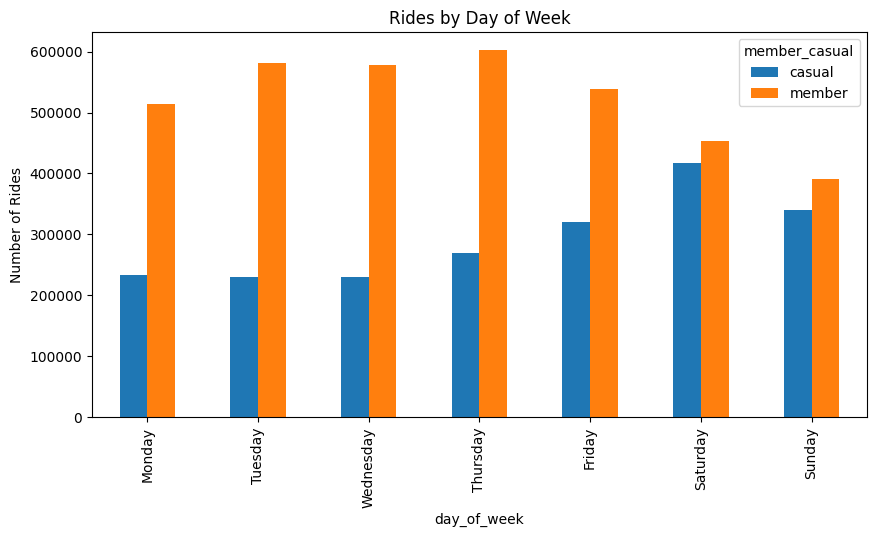

In [61]:

# Rides by day of week

pivot = df.groupby(['day_of_week', 'member_casual'])['ride_id'].count().unstack().reindex(weekday_order)
pivot.plot(kind='bar', figsize=(10,5), title='Rides by Day of Week')
plt.ylabel('Number of Rides')
plt.show()

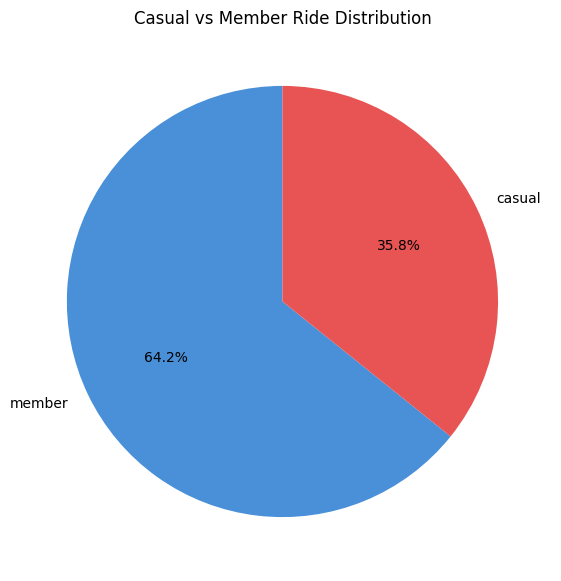

In [62]:
import matplotlib.pyplot as plt

member_counts = df['member_casual'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    member_counts,
    labels=member_counts.index,
    autopct='%1.1f%%',
    colors=['#4A90D9', '#E85454'],
    startangle=90
)
plt.title('Casual vs Member Ride Distribution')
plt.show()

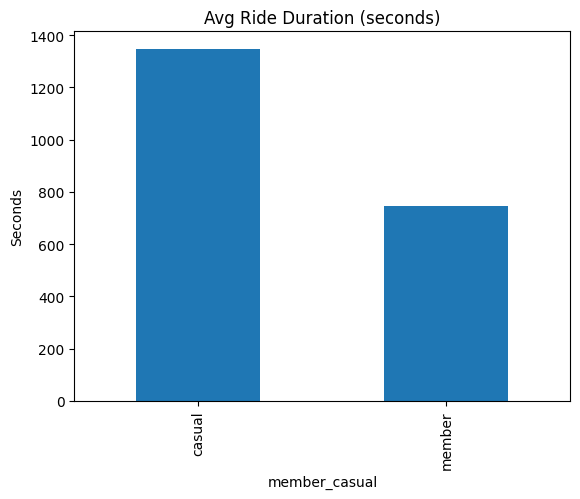

In [63]:
df.groupby('member_casual')['ride_length_seconds'].mean().plot(kind='bar', title='Avg Ride Duration (seconds)')
plt.ylabel('Seconds')
plt.show()

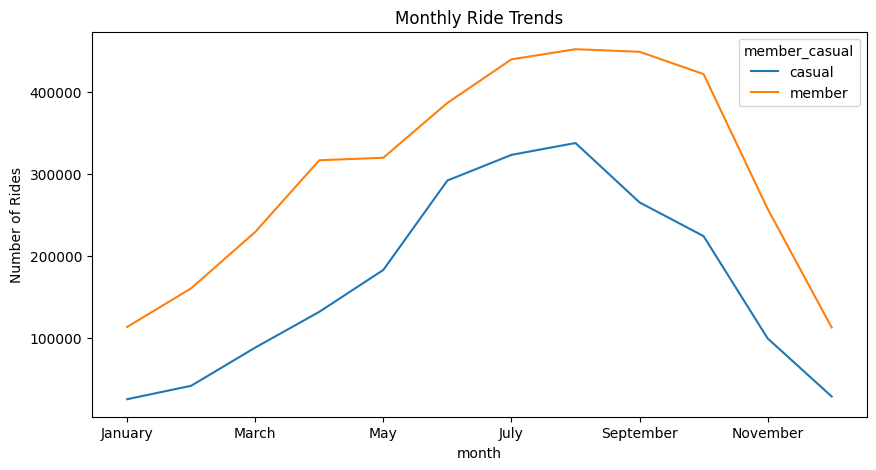

In [64]:

pivot2 = df.groupby(['month','member_casual'])['ride_id'].count().unstack().reindex(month_order)
pivot2.plot(kind='line', figsize=(10,5), title='Monthly Ride Trends')
plt.ylabel('Number of Rides')
plt.show()

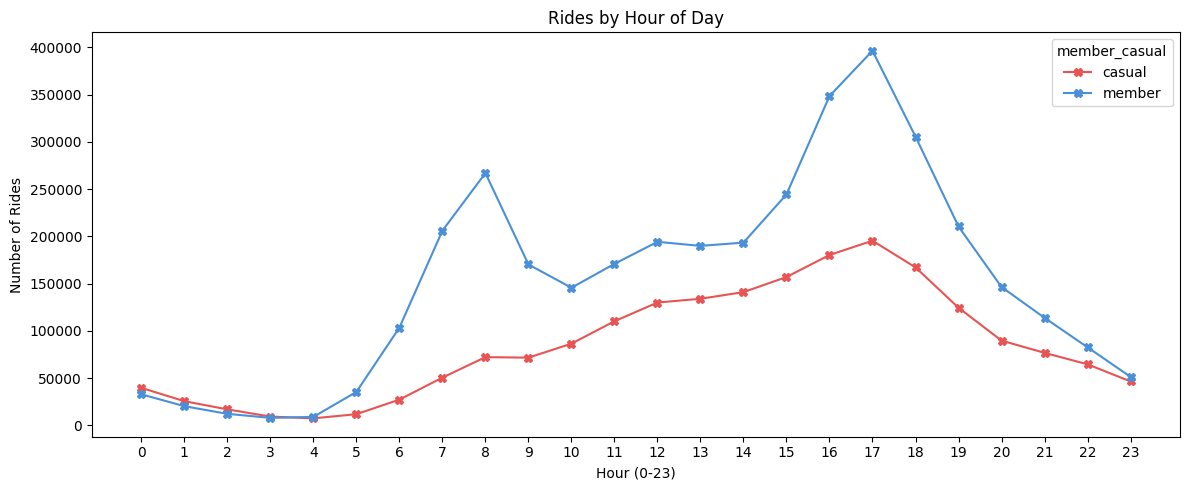

In [78]:
pivot3 = df.groupby(['hour','member_casual'])['ride_id'].count().unstack()
pivot3.plot(kind='line', figsize=(12,5), color=['#E85454','#4A90D9'],
            title='Rides by Hour of Day', marker='X')
plt.xlabel('Hour (0-23)')
plt.ylabel('Number of Rides')
plt.xticks(range(0,24))
plt.tight_layout()
plt.show()

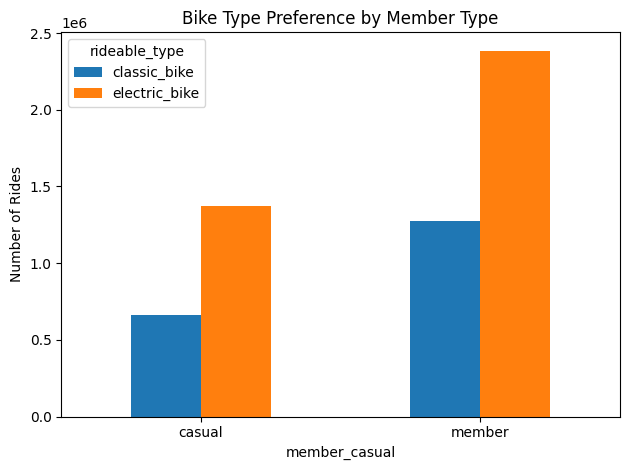

In [80]:
# 5. Bike type preference by member type
df.groupby(['member_casual','rideable_type'])['ride_id'].count().unstack().plot(
    kind='bar',
    title='Bike Type Preference by Member Type')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [66]:
# top 20 station names
top_20_stations = df['start_station_name'].value_counts().head(20).index

df[df['start_station_name'].isin(top_20_stations)]\
  .groupby(['start_station_name', 'rideable_type'])['ride_id']\
  .count()\
  .unstack()\
  .fillna(0)\
  .sort_values('classic_bike', ascending=False)

rideable_type,classic_bike,electric_bike
start_station_name,,
Navy Pier,23109,19746
DuSable Lake Shore Dr & Monroe St,22456,17780
DuSable Lake Shore Dr & North Blvd,19986,14379
Michigan Ave & Oak St,19161,16635
Theater on the Lake,16767,10751
Streeter Dr & Grand Ave,14662,9237
Millennium Park,14344,13231
Kingsbury St & Kinzie St,13180,17833
Clark St & Elm St,12944,15073


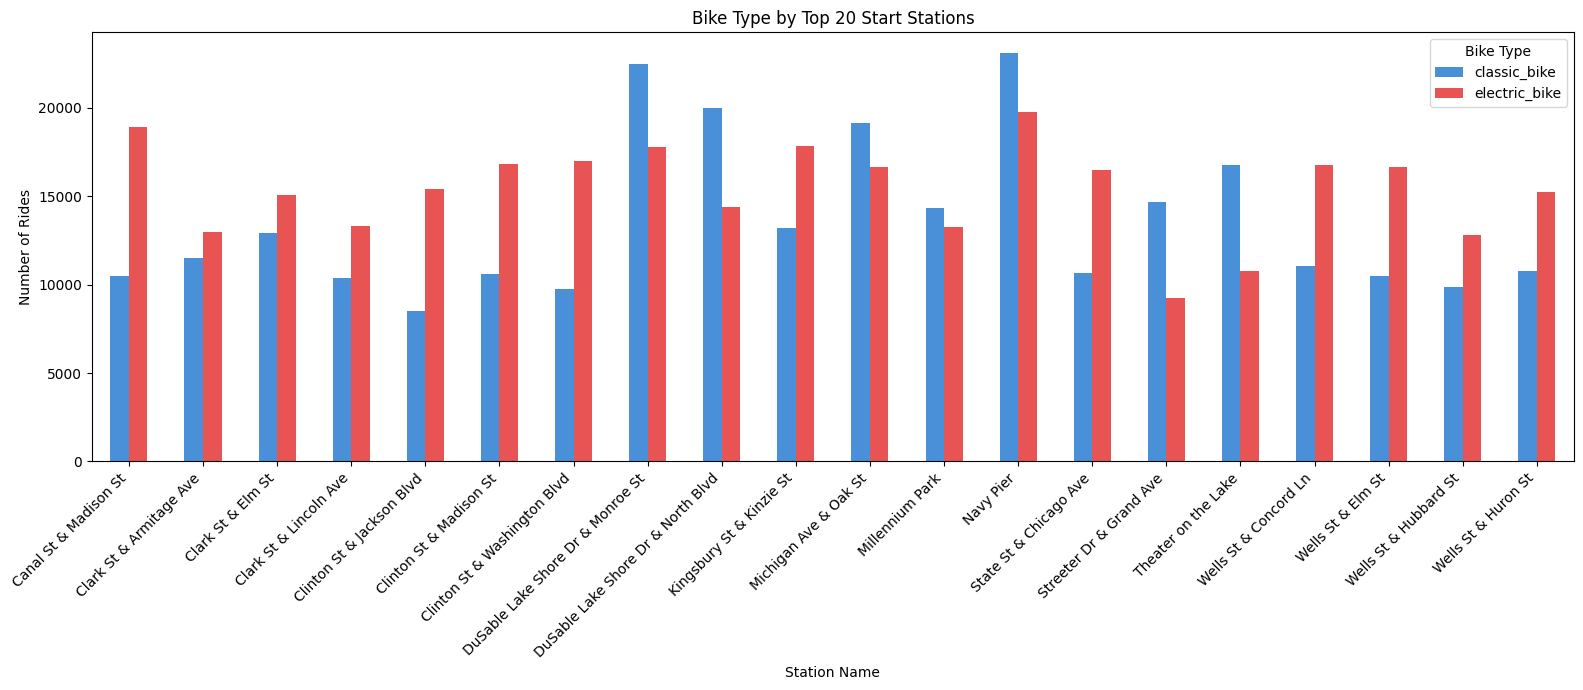

In [68]:
top_20_stations = df['start_station_name'].value_counts().head(20).index

top_station_bike = df[df['start_station_name'].isin(top_20_stations)]\
  .groupby(['start_station_name', 'rideable_type'])['ride_id']\
  .count().unstack().fillna(0)

top_station_bike.plot(
    kind='bar',
    figsize=(16, 7),
    color=['#4A90D9', '#E85454', '#2ECC71'],
    title='Bike Type by Top 20 Start Stations'
)
plt.xlabel('Station Name')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Bike Type')
plt.tight_layout()
plt.show()